In [2]:
import numpy as np
import torch
from skimage import io, transform
from segment_anything import sam_model_registry
import matplotlib.pyplot as plt
import os
import SimpleITK as sitk
from pathlib import Path
import glob
from PIL import Image

from torch.utils.data import DataLoader
from torch.utils.data import Subset
from torchvision import transforms, datasets
from pytorch_ood.detector import Mahalanobis
from pytorch_ood.utils import OODMetrics, ToUnknown, fix_random_seed

from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
from torchvision.io import decode_image

from collections import defaultdict
import random

In [27]:
device = "cuda:1"
ckpt = "../work_dir/MedSAM/sam_vit_b_01ec64.pth"

# build model WITHOUT checkpoint
model = sam_model_registry["vit_b"](checkpoint=None)

# load checkpoint safely on CPU
state_dict = torch.load(ckpt, map_location="cpu")

# load weights into model
model.load_state_dict(state_dict)

# now move model to the target GPU
model = model.to(device).eval()

In [4]:
from pathlib import Path
import random

import torch
from torch.utils.data import Dataset
from torchvision.io import decode_image


class PhaKIRDataset(Dataset):
    def __init__(
        self,
        root,
        domains,
        label,
        split="all",
        train_ratio=0.7,
        seed=42,
        transform=None,
        limit_images=None,
    ):
        """
        Parameters
        ----------
        root : str or Path
            Root directory containing domain folders.
        domains : list[str]
            Which domains to include, e.g. ["video_01"].
        label : int
            Label to assign to all samples from these domains.
            Use 0 for ID, -1 for OOD.
        split : str
            "train", "test", or "all"
        train_ratio : float
            Fraction of images used for train split.
        seed : int
            Random seed for reproducible splitting.
        transform : callable or None
            Optional transform applied to image tensor.
        limit_images : int or None
            Optional limit on number of images.
        """
        self.root = Path(root)
        self.domains = domains
        self.label = label
        self.split = split
        self.train_ratio = train_ratio
        self.seed = seed
        self.transform = transform

        samples = []

        valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

        for domain in domains:
            domain_dir = self.root / domain
            if not domain_dir.exists():
                raise FileNotFoundError(f"Domain folder not found: {domain_dir}")

            image_files = sorted(
                [
                    p for p in domain_dir.rglob("*")
                    if p.is_file()
                    and p.suffix.lower() in valid_exts
                    and not any(part.startswith(".") for part in p.parts)
                ]
            )

            for img_path in image_files:
                samples.append(
                    {
                        "path": img_path,
                        "label": label,
                        "domain": domain,
                        "image_id": img_path.stem,
                    }
                )

        if len(samples) == 0:
            raise RuntimeError(f"No images found under root={self.root} for domains={domains}")

        # Reproducible shuffle and split at image level
        rng = random.Random(seed)
        rng.shuffle(samples)

        if limit_images is not None:
            samples = samples[:limit_images]

        n_train = int(round(len(samples) * train_ratio))

        if split == "train":
            self.samples = samples[:n_train]
        elif split == "test":
            self.samples = samples[n_train:]
        elif split == "all":
            self.samples = samples
        else:
            raise ValueError(f"Unknown split: {split}")

        self.image_ids = [s["image_id"] for s in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        img_path = item["path"]

        image = decode_image(str(img_path)).float() / 255.0  # [C,H,W]

        if image.ndim == 2:
            image = image.unsqueeze(0)
        elif image.ndim == 3 and image.shape[-1] in (1, 3) and image.shape[0] not in (1, 3):
            image = image.permute(2, 0, 1)

        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(item["label"], dtype=torch.long),
            "domain": item["domain"],
            "image_id": item["image_id"],
            "path": str(img_path),
        }
        
        
        
class AddGaussianNoiseOOD(Dataset):
    def __init__(self, base_dataset, std=0.01, clamp=True):
        self.base_dataset = base_dataset
        self.std = std
        self.clamp = clamp

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        sample = self.base_dataset[idx]

        # copy dict so we do not modify original sample in place
        sample = dict(sample)

        img = sample["image"].clone().float()

        noise = torch.randn_like(img) * self.std
        img_noisy = img + noise

        if self.clamp:
            img_noisy = torch.clamp(img_noisy, 0.0, 1.0)

        sample["image"] = img_noisy
        return sample
    
    
    

In [5]:
def summarize_dataset(ds, name):
    print(f"{name}:")
    print(f"  patches     = {len(ds)}")
    print(f"  domains     = {sorted(ds.domains)}")

In [28]:
ROOT = "/home/jovyan/thesis_project/datasets/prep_datasets/phaKIR"

ID_DOMAINS = ["video_01_frames"]
OOD_DOMAINS = ["video_01_smoke"]

id_train_ds = PhaKIRDataset(
    root=ROOT,
    domains=ID_DOMAINS,
    label=0,
    split="train",
    train_ratio=0.7,
    seed=42,
    transform=None,
)

id_test_ds = PhaKIRDataset(
    root=ROOT,
    domains=ID_DOMAINS,
    label=0,
    split="test",
    train_ratio=0.7,
    seed=42,
    transform=None,
)

ood_test_ds = PhaKIRDataset(
    root=ROOT,
    domains=OOD_DOMAINS,
    label=-1,
    split="all",
    train_ratio=0.7,
    seed=42,
    transform=None,
)


# ood_test_ds_noisy = AddGaussianNoiseOOD(ood_test_ds, std=0.1)


summarize_dataset(id_train_ds, "ID train")
summarize_dataset(id_test_ds, "ID test")
summarize_dataset(ood_test_ds, "OOD test")

ID train:
  patches     = 299
  domains     = ['video_01_frames']
ID test:
  patches     = 128
  domains     = ['video_01_frames']
OOD test:
  patches     = 295
  domains     = ['video_01_smoke']


In [29]:
id_train_loader = DataLoader(id_train_ds, batch_size=4, shuffle=False, num_workers=0)
id_test_loader  = DataLoader(id_test_ds,  batch_size=4, shuffle=False, num_workers=0)
ood_test_loader = DataLoader(ood_test_ds, batch_size=4, shuffle=False, num_workers=0)


# ood_test_loader_noisy = DataLoader(
#     ood_test_ds_noisy,
#     batch_size=4,
#     shuffle=False,
#     num_workers=4,
#     pin_memory=True,
# )

### Some different feature extractors: medSAM, RGB mean etc.

In [30]:
def extract_features(loader, model, device):
    feats = []
    labels = []
    image_ids = []
    domains = []
    paths = []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            y = batch["label"]

            z = model.image_encoder(imgs)      # [B, C, H, W]
            z = z.mean(dim=(2, 3))             # [B, C]

            feats.append(z.cpu())
            labels.append(y.cpu())
            image_ids.extend(batch["image_id"])
            domains.extend(batch["domain"])
            paths.extend(batch["path"])

    return {
        "features": torch.cat(feats, dim=0),
        "labels": torch.cat(labels, dim=0),
        "image_ids": image_ids,
        "domains": domains,
        "paths": paths,
    }



def extract_mean_rgb_features(loader):
    feats = []
    labels = []
    source_ids = []
    domains = []
    paths = []

    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].float()   # [B, C, H, W], already in [0, 1] in your dataset
            y = batch["label"]

            # Ensure 3 channels
            if imgs.shape[1] == 1:
                imgs = imgs.repeat(1, 3, 1, 1)
            elif imgs.shape[1] != 3:
                raise ValueError(f"Expected 1 or 3 channels, got {imgs.shape}")

            # Mean RGB per patch -> [B, 3]
            z = imgs.mean(dim=(2, 3))

            feats.append(z.cpu())
            labels.append(y.cpu())
            source_ids.extend(batch["source_id"])
            domains.extend(batch["domain"])
            paths.extend(batch["path"])

    return {
        "features": torch.cat(feats, dim=0),   # [N, 3]
        "labels": torch.cat(labels, dim=0),
        "source_ids": source_ids,
        "domains": domains,
        "paths": paths,
    }

In [31]:
from pytorch_ood.detector import Mahalanobis


id_train_data = extract_features(id_train_loader, model, device)
id_test_data  = extract_features(id_test_loader, model, device)
ood_test_data = extract_features(ood_test_loader, model, device)
#ood_test_data_noisy = extract_features(ood_test_loader_noisy, model, device)


# id_train_data = extract_mean_rgb_features(id_train_loader)
# id_test_data  = extract_mean_rgb_features(id_test_loader)
# #ood_test_data = extract_mean_rgb_features(ood_test_loader)
# ood_test_data_noisy = extract_mean_rgb_features(ood_test_loader_noisy)


Z_id_train = id_train_data["features"]
Y_id_train = id_train_data["labels"]

detector = Mahalanobis(model=None)
detector.fit_features(Z_id_train, Y_id_train)

No device given. Will use 'cpu'.


### Score held-out ID and OOD

In [32]:
scores_id_test = detector.predict_features(id_test_data["features"]).detach().cpu()
scores_ood_test = detector.predict_features(ood_test_data["features"]).detach().cpu()

### Aggregate patch scores to image-level scores

### Image-level metrics

In [33]:
img_scores = torch.cat([scores_id_test, scores_ood_test], dim=0)
img_labels = torch.cat([
    torch.zeros(len(scores_id_test), dtype=torch.long),
    -torch.ones(len(scores_ood_test), dtype=torch.long),
], dim=0)

metrics = OODMetrics()
metrics.update(img_scores, img_labels)
img_result = metrics.compute()

print("Image-level metrics:")
print(img_result)

Image-level metrics:
{'AUROC': 0.8860170245170593, 'AUTC': 0.44623804092407227, 'AUPR-IN': 0.8440980315208435, 'AUPR-OUT': 0.9209986329078674, 'FPR95TPR': 0.328125}


In [19]:
id_scores = scores_id_test
#id_labels = id_img["labels"]  # usually all same class


print("ID stats:")
print("mean:", id_scores.mean().item())
print("std:", id_scores.std().item())
print("min:", id_scores.min().item())
print("max:", id_scores.max().item())

ID stats:
mean: 1.7546229362487793
std: 2.1398696899414062
min: 0.2401474267244339
max: 13.153274536132812


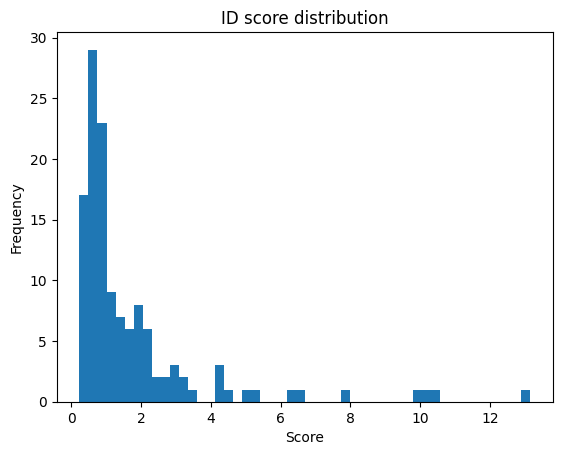

In [20]:
import matplotlib.pyplot as plt

plt.hist(id_scores.numpy(), bins=50)
plt.title("ID score distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [21]:
ood_scores = scores_ood_test
#ood_labels = ood_img["labels"]  # usually all same class


print("ID stats:")
print("mean:", ood_scores.mean().item())
print("std:", ood_scores.std().item())
print("min:", ood_scores.min().item())
print("max:", ood_scores.max().item())

ID stats:
mean: 7.027683258056641
std: 4.590564727783203
min: 0.5615221858024597
max: 24.47085189819336


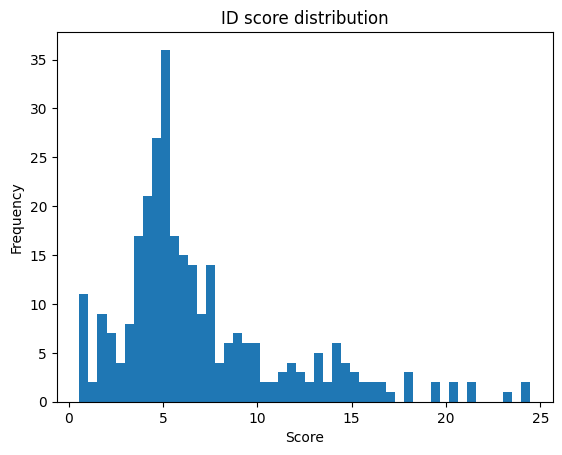

In [22]:
import matplotlib.pyplot as plt

plt.hist(ood_scores.numpy(), bins=50)
plt.title("ID score distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

### Debug inspection

In [23]:
sid = scores_id_test.numpy()
sood = scores_ood_test.numpy()

print("ID  mean/std:", sid.mean(), sid.std(), "min/max:", sid.min(), sid.max())
print("OOD mean/std:", sood.mean(), sood.std(), "min/max:", sood.min(), sood.max())

ID  mean/std: 1.7546229 2.1314945 min/max: 0.24014743 13.153275
OOD mean/std: 7.0276833 4.5827775 min/max: 0.5615222 24.470852


In [30]:
import matplotlib.pyplot as plt
import torch

def show_id_ood_samples(id_loader, ood_loader, num_rows=3, num_cols=6):
    """
    Visualize ID vs OOD samples.
    
    Each row:
        left half  -> ID samples
        right half -> OOD samples
    """
    fig, axes = plt.subplots(num_rows, num_cols * 2, figsize=(3 * num_cols, 3 * num_rows))

    id_iter = iter(id_loader)
    ood_iter = iter(ood_loader)

    for row in range(num_rows):
        try:
            id_batch = next(id_iter)
        except StopIteration:
            id_iter = iter(id_loader)
            id_batch = next(id_iter)

        try:
            ood_batch = next(ood_iter)
        except StopIteration:
            ood_iter = iter(ood_loader)
            ood_batch = next(ood_iter)

        id_imgs = id_batch["image"]
        ood_imgs = ood_batch["image"]

        for col in range(num_cols):
            # --- ID ---
            ax = axes[row, col]
            img = id_imgs[col]

            img = img.permute(1, 2, 0).cpu().numpy()  # [H, W, C]

            if img.shape[2] == 1:
                ax.imshow(img.squeeze(-1), cmap="gray")
            else:
                ax.imshow(img)

            ax.set_title(f"ID\n{str(id_batch['domain'][col])}")
            ax.axis("off")

            # --- OOD ---
            ax = axes[row, col + num_cols]
            img = ood_imgs[col]

            img = img.permute(1, 2, 0).cpu().numpy()

            if img.shape[2] == 1:
                ax.imshow(img.squeeze(-1), cmap="gray")
            else:
                ax.imshow(img)

            ax.set_title(f"OOD\n{str(ood_batch['domain'][col])}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

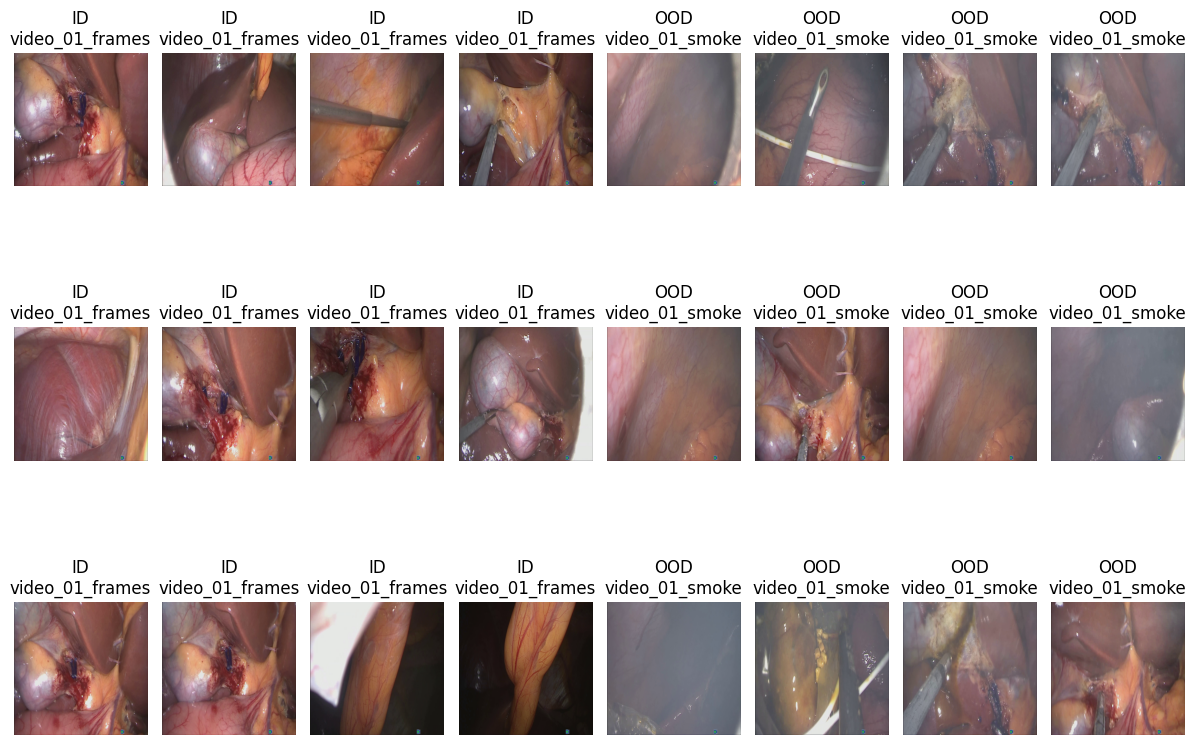

In [32]:
show_id_ood_samples(id_train_loader, ood_test_loader, num_rows=3, num_cols=4)